# Telco Customer Churn Analysis — End-to-End Internship Project

**Objective:** Clean customer/subscription data, analyze churn and retention, create lifecycle cohorts, study customer lifetime/value, identify churn drivers, score customer risk, and translate findings into business recommendations.

**Dataset limitation:** The supplied data has no signup date, region, or explicit churn-reason field. This project therefore uses **tenure bands as lifecycle cohorts** and does not invent unavailable fields.

## Workflow
1. Load data
2. Audit data quality
3. Clean and transform
4. Calculate churn/retention KPIs
5. Analyze lifecycle cohorts
6. Analyze contract, service, billing and payment segments
7. Analyze customer lifetime/value
8. Perform chi-square and t-tests
9. Build logistic-regression churn model
10. Generate customer-level risk scores
11. Export tables/charts
12. Form management recommendations

In [7]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_PATH = Path("WA_Fn-UseC_-Telco-Customer-Churn.csv")
OUTPUT_DIR = Path("churn_project_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42

In [8]:
# Load data
df_raw = pd.read_csv(DATA_PATH)
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])
display(df_raw.head())

Rows: 7043
Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
# Data-quality audit
audit = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing_count": df_raw.isna().sum(),
    "missing_pct": (df_raw.isna().mean() * 100).round(2),
    "unique_values": df_raw.nunique()
})
print("Duplicate rows:", df_raw.duplicated().sum())
print("Unique customer IDs:", df_raw["customerID"].nunique())
display(audit)
display(df_raw["Churn"].value_counts())

Duplicate rows: 0
Unique customer IDs: 7043


,dtype,missing_count,missing_pct,unique_values
customerID,str,0,0.00,7043
gender,str,0,0.00,2
SeniorCitizen,int64,0,0.00,2
Partner,str,0,0.00,2
Dependents,str,0,0.00,2
tenure,int64,0,0.00,73
PhoneService,str,0,0.00,2
MultipleLines,str,0,0.00,3
InternetService,str,0,0.00,3
OnlineSecurity,str,0,0.00,3


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
# Cleaning + feature engineering
df = df_raw.copy()

# Remove whitespace from text fields
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

# TotalCharges is text in the source file
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Keep one record per customer
df = df.drop_duplicates(subset="customerID", keep="first").copy()

# Blank TotalCharges occurs for some zero-tenure customers
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Target
df["ChurnFlag"] = df["Churn"].map({"No": 0, "Yes": 1})

# Lifecycle cohorts
df["TenureBand"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=["0–6 months", "7–12 months", "13–24 months", "25–48 months", "49–72 months"]
)

# Value proxies
df["AnnualizedMonthlyRevenue"] = df["MonthlyCharges"] * 12
df["AvgMonthlyValue"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)

print("Cleaned shape:", df.shape)
display(df.head())

Cleaned shape: (7043, 25)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag,TenureBand,AnnualizedMonthlyRevenue,AvgMonthlyValue
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0–6 months,358.20,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,"1,889.50",No,0,25–48 months,683.40,55.57
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0–6 months,646.20,54.08
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,"1,840.75",No,0,25–48 months,507.60,40.91
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0–6 months,848.40,75.83


In [11]:
# Validate cleaning
quality_after = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
})
display(quality_after[quality_after["missing_count"] > 0])
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())
print("Missing target values:", df["ChurnFlag"].isna().sum())

,dtype,missing_count,missing_pct


Duplicate customer IDs: 0
Missing target values: 0


## Executive KPIs

In [12]:
total_customers = len(df)
churned = int(df["ChurnFlag"].sum())
retained = total_customers - churned
churn_rate = churned / total_customers
retention_rate = 1 - churn_rate

kpis = pd.DataFrame({
    "KPI": [
        "Customers", "Churned Customers", "Retained Customers",
        "Churn Rate", "Retention Rate",
        "Average Tenure (months)", "Average Monthly Charges",
        "Average Total Charges"
    ],
    "Value": [
        total_customers, churned, retained, churn_rate, retention_rate,
        df["tenure"].mean(), df["MonthlyCharges"].mean(), df["TotalCharges"].mean()
    ]
})
display(kpis)

,KPI,Value
0,Customers,"7,043.00"
1,Churned Customers,"1,869.00"
2,Retained Customers,"5,174.00"
3,Churn Rate,0.27
4,Retention Rate,0.73
5,Average Tenure (months),32.37
6,Average Monthly Charges,64.76
7,Average Total Charges,"2,279.73"


## Churn & Retention

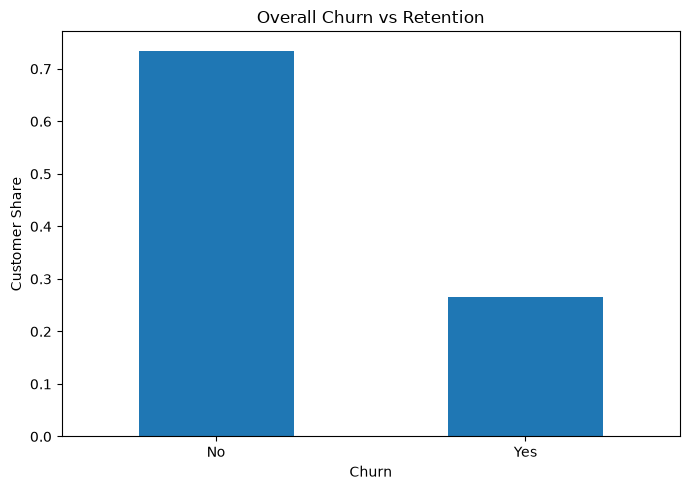

In [13]:
overall = df["Churn"].value_counts(normalize=True)
plt.figure(figsize=(7,5))
overall.plot(kind="bar")
plt.title("Overall Churn vs Retention")
plt.ylabel("Customer Share")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_overall_churn_retention.png", dpi=200)
plt.show()

,TenureBand,Customers,ChurnRate
0,0–6 months,1481,52.9%
1,7–12 months,705,35.9%
2,13–24 months,1024,28.7%
3,25–48 months,1594,20.4%
4,49–72 months,2239,9.5%


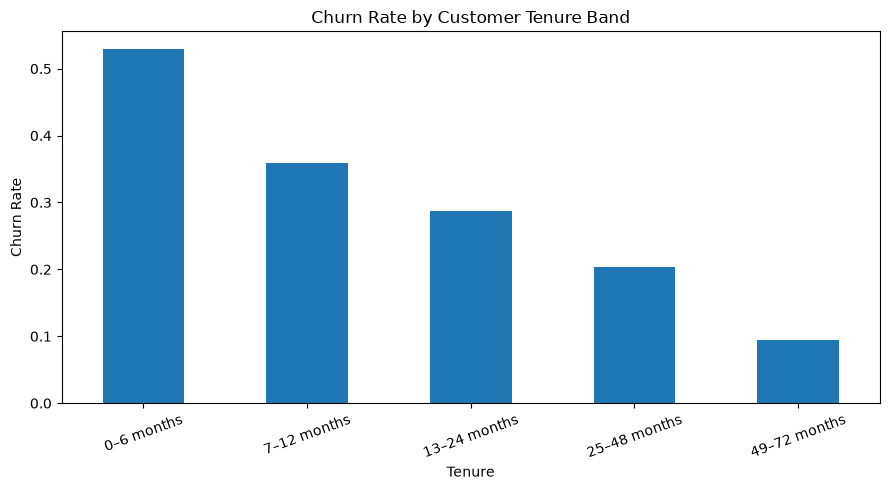

In [14]:
tenure_churn = (
    df.groupby("TenureBand", observed=False)["ChurnFlag"]
      .agg(Customers="count", ChurnRate="mean")
      .reset_index()
)
display(tenure_churn.style.format({"ChurnRate": "{:.1%}"}))

plt.figure(figsize=(9,5))
tenure_churn.set_index("TenureBand")["ChurnRate"].plot(kind="bar")
plt.title("Churn Rate by Customer Tenure Band")
plt.ylabel("Churn Rate")
plt.xlabel("Tenure")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_churn_by_tenure.png", dpi=200)
plt.show()

**Interpretation:** This is a lifecycle trend rather than a calendar-time trend. The dataset has no signup/cancellation dates, so exact monthly retention curves cannot be reconstructed.

## Cohort / Segment Analysis

In [15]:
def segment_churn(data, col):
    return (
        data.groupby(col, dropna=False)["ChurnFlag"]
            .agg(Customers="count", ChurnRate="mean")
            .reset_index()
            .sort_values("ChurnRate", ascending=False)
    )

for col in [
    "Contract", "InternetService", "PaymentMethod", "PaperlessBilling",
    "SeniorCitizen", "Partner", "Dependents", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "MultipleLines"
]:
    print(f"--- {col} ---")
    display(segment_churn(df, col).style.format({"ChurnRate": "{:.1%}"}))

--- Contract ---


,Contract,Customers,ChurnRate
0,Month-to-month,3875,42.7%
1,One year,1473,11.3%
2,Two year,1695,2.8%


--- InternetService ---


,InternetService,Customers,ChurnRate
1,Fiber optic,3096,41.9%
0,DSL,2421,19.0%
2,No,1526,7.4%


--- PaymentMethod ---


...

,StreamingTV,Customers,ChurnRate
0,No,2810,33.5%
2,Yes,2707,30.1%
1,No internet service,1526,7.4%


--- StreamingMovies ---


,StreamingMovies,Customers,ChurnRate
0,No,2785,33.7%
2,Yes,2732,29.9%
1,No internet service,1526,7.4%


--- MultipleLines ---


,MultipleLines,Customers,ChurnRate
2,Yes,2971,28.6%
0,No,3390,25.0%
1,No phone service,682,24.9%


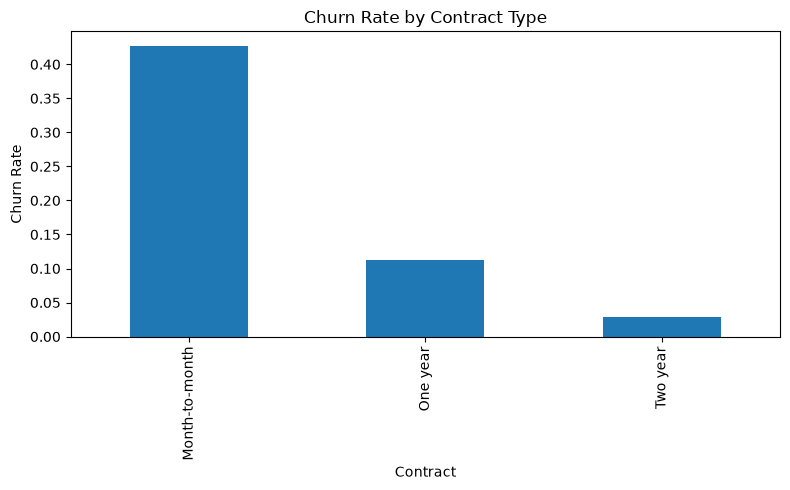

In [16]:
contract_churn = segment_churn(df, "Contract")
plt.figure(figsize=(8,5))
contract_churn.set_index("Contract")["ChurnRate"].plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_churn_by_contract.png", dpi=200)
plt.show()

## Customer Lifetime & Value

,TenureBand,Customers,AvgTenure,AvgMonthlyCharges,AvgTotalCharges,ChurnRate
0,0–6 months,1481,2.5,$54.74,$142.57,52.9%
1,7–12 months,705,9.4,$58.95,$553.91,35.9%
2,13–24 months,1024,18.4,$61.36,"$1,126.26",28.7%
3,25–48 months,1594,36.2,$65.93,"$2,390.45",20.4%
4,49–72 months,2239,63.0,$73.95,"$4,685.51",9.5%


<Figure size 900x500 with 0 Axes>

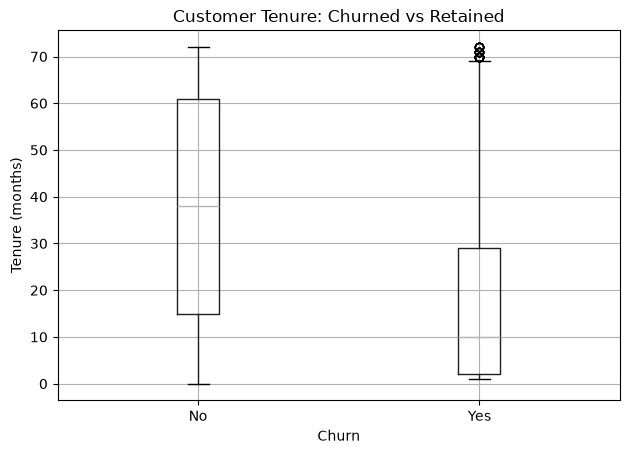

<Figure size 900x500 with 0 Axes>

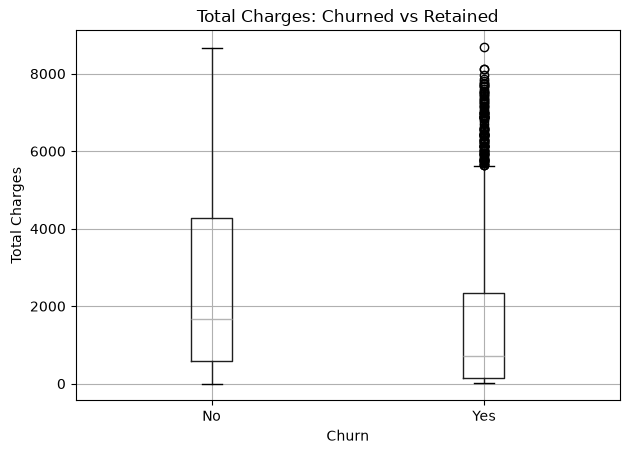

In [17]:
lifetime_summary = df.groupby("TenureBand", observed=False).agg(
    Customers=("customerID", "count"),
    AvgTenure=("tenure", "mean"),
    AvgMonthlyCharges=("MonthlyCharges", "mean"),
    AvgTotalCharges=("TotalCharges", "mean"),
    ChurnRate=("ChurnFlag", "mean")
).reset_index()

display(lifetime_summary.style.format({
    "AvgTenure": "{:.1f}",
    "AvgMonthlyCharges": "${:,.2f}",
    "AvgTotalCharges": "${:,.2f}",
    "ChurnRate": "{:.1%}"
}))

for metric, filename, title, ylabel in [
    ("tenure", "04_tenure_churn_boxplot.png", "Customer Tenure: Churned vs Retained", "Tenure (months)"),
    ("TotalCharges", "05_totalcharges_churn_boxplot.png", "Total Charges: Churned vs Retained", "Total Charges")
]:
    plt.figure(figsize=(9,5))
    df.boxplot(column=metric, by="Churn")
    plt.title(title)
    plt.suptitle("")
    plt.xlabel("Churn")
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=200)
    plt.show()

## Revenue at Risk

In [18]:
revenue_at_risk = df.loc[df["ChurnFlag"] == 1, "MonthlyCharges"].sum()
total_monthly_revenue = df["MonthlyCharges"].sum()

revenue_summary = pd.DataFrame({
    "Metric": [
        "Total Monthly Charges",
        "Monthly Charges Associated With Churned Customers",
        "Share of Monthly Charges Associated With Churned Customers"
    ],
    "Value": [
        total_monthly_revenue,
        revenue_at_risk,
        revenue_at_risk / total_monthly_revenue
    ]
})
display(revenue_summary)

,Metric,Value
0,Total Monthly Charges,"456,116.60"
1,Monthly Charges Associated With Churned Customers,"139,130.85"
2,Share of Monthly Charges Associated With Churn...,0.31


## Statistical Significance

In [19]:
categorical_features_for_test = [
    "Contract", "InternetService", "PaymentMethod", "PaperlessBilling",
    "SeniorCitizen", "Partner", "Dependents", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "MultipleLines"
]

chi_results = []
for col in categorical_features_for_test:
    table = pd.crosstab(df[col], df["Churn"])
    chi2, p, dof, expected = chi2_contingency(table)
    chi_results.append({
        "Feature": col,
        "Chi2": chi2,
        "p_value": p,
        "Significant_at_5pct": p < 0.05
    })

chi_results = pd.DataFrame(chi_results).sort_values("p_value")
display(chi_results.style.format({"Chi2": "{:.2f}", "p_value": "{:.6f}"}))

,Feature,Chi2,p_value,Significant_at_5pct
0,Contract,1184.60,0.000000,True
7,OnlineSecurity,850.00,0.000000,True
10,TechSupport,828.20,0.000000,True
1,InternetService,732.31,0.000000,True
2,PaymentMethod,648.14,0.000000,True
8,OnlineBackup,601.81,0.000000,True
9,DeviceProtection,558.42,0.000000,True
12,StreamingMovies,375.66,0.000000,True
11,StreamingTV,374.20,0.000000,True
3,PaperlessBilling,258.28,0.000000,True


In [20]:
ttest_results = []
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    churned_values = df.loc[df["ChurnFlag"] == 1, col]
    retained_values = df.loc[df["ChurnFlag"] == 0, col]
    stat, p = ttest_ind(churned_values, retained_values, equal_var=False)
    ttest_results.append({
        "Feature": col,
        "ChurnedMean": churned_values.mean(),
        "RetainedMean": retained_values.mean(),
        "t_statistic": stat,
        "p_value": p,
        "Significant_at_5pct": p < 0.05
    })

ttest_results = pd.DataFrame(ttest_results)
display(ttest_results.style.format({
    "ChurnedMean": "{:.2f}", "RetainedMean": "{:.2f}",
    "t_statistic": "{:.2f}", "p_value": "{:.6f}"
}))

,Feature,ChurnedMean,RetainedMean,t_statistic,p_value,Significant_at_5pct
0,tenure,17.98,37.57,-34.82,0.000000,True
1,MonthlyCharges,74.44,61.27,18.41,0.000000,True
2,TotalCharges,1531.80,2549.91,-18.71,0.000000,True


## Churn Driver Model

Logistic regression is used as a **predictive/associational model**. A positive coefficient means higher modeled churn odds relative to the reference category, while a negative coefficient means lower modeled churn odds. This is not proof of causality.

In [21]:
# Prepare model data
X = df.drop(columns=["customerID", "Churn", "ChurnFlag"])
y = df["ChurnFlag"]

categorical_features = X.select_dtypes(include="object").columns.tolist()
if "TenureBand" in X.columns:
    categorical_features.append("TenureBand")
categorical_features = list(dict.fromkeys(categorical_features))
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
    ]), categorical_features)
])

model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
proba = pipe.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, pred), 4))
print("Precision:", round(precision_score(y_test, pred), 4))
print("Recall   :", round(recall_score(y_test, pred), 4))
print("F1 Score :", round(f1_score(y_test, pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, proba), 4))
print("\nClassification report:")
print(classification_report(y_test, pred))

display(pd.DataFrame(
    confusion_matrix(y_test, pred),
    index=["Actual No Churn", "Actual Churn"],
    columns=["Pred No Churn", "Pred Churn"]
))

Accuracy : 0.7388
Precision: 0.505
Recall   : 0.8048
F1 Score : 0.6206
ROC-AUC  : 0.8452

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



,Pred No Churn,Pred Churn
Actual No Churn,740,295
Actual Churn,73,301


Top associations with higher churn:


,Feature,Coefficient,OddsRatio
12,cat__InternetService_Fiber optic,1.27,3.56
25,cat__StreamingMovies_Yes,0.46,1.59
23,cat__StreamingTV_Yes,0.44,1.55
11,cat__MultipleLines_Yes,0.38,1.47
30,cat__PaymentMethod_Electronic check,0.37,1.45
28,cat__PaperlessBilling_Yes,0.35,1.42
5,num__AvgMonthlyValue,0.16,1.17
19,cat__DeviceProtection_Yes,0.08,1.08
0,num__SeniorCitizen,0.06,1.06
3,num__TotalCharges,0.05,1.05


Top associations with lower churn:


,Feature,Coefficient,OddsRatio
27,cat__Contract_Two year,-1.57,0.21
32,cat__TenureBand_13–24 months,-0.76,0.47
33,cat__TenureBand_25–48 months,-0.74,0.48
26,cat__Contract_One year,-0.72,0.49
1,num__tenure,-0.67,0.51
35,cat__TenureBand_7–12 months,-0.63,0.53
34,cat__TenureBand_49–72 months,-0.46,0.63
4,num__AnnualizedMonthlyRevenue,-0.31,0.73
2,num__MonthlyCharges,-0.31,0.73
15,cat__OnlineSecurity_Yes,-0.29,0.75


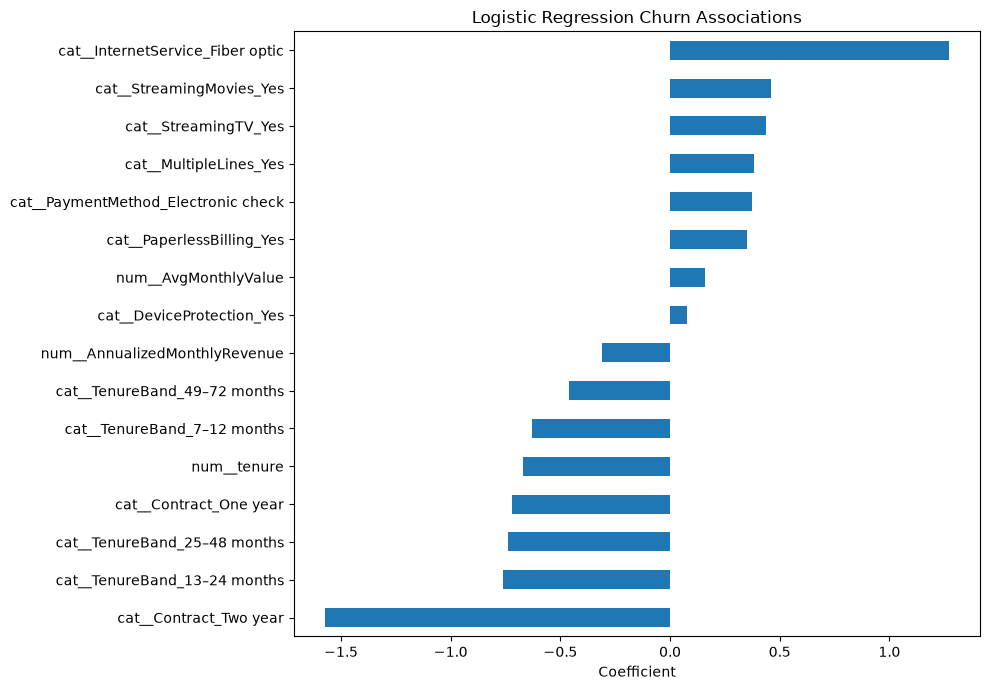

In [22]:
# Odds ratios / driver ranking
feature_names = pipe.named_steps["preprocessor"].get_feature_names_out()
coefficients = pipe.named_steps["model"].coef_[0]

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "OddsRatio": np.exp(coefficients)
}).sort_values("Coefficient", ascending=False)

print("Top associations with higher churn:")
display(importance.head(15))

print("Top associations with lower churn:")
display(importance.tail(15).sort_values("Coefficient"))

top_plot = pd.concat([importance.head(8), importance.tail(8)]).sort_values("Coefficient")
plt.figure(figsize=(10,7))
top_plot.set_index("Feature")["Coefficient"].plot(kind="barh")
plt.title("Logistic Regression Churn Associations")
plt.xlabel("Coefficient")
plt.ylabel("")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_logistic_churn_drivers.png", dpi=200)
plt.show()

## Customer-Level Churn Risk Scoring

In [23]:
df_scored = df.copy()
df_scored["ChurnRiskScore"] = pipe.predict_proba(X)[:, 1]
df_scored["RiskTier"] = pd.cut(
    df_scored["ChurnRiskScore"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=["Low", "Medium", "High"]
)

risk_summary = (
    df_scored["RiskTier"].value_counts()
    .rename_axis("RiskTier")
    .reset_index(name="Customers")
)
risk_summary["Share"] = risk_summary["Customers"] / len(df_scored)
display(risk_summary.style.format({"Share": "{:.1%}"}))

retention_priority = (
    df_scored.sort_values("ChurnRiskScore", ascending=False)
    [["customerID", "Contract", "tenure", "MonthlyCharges", "TotalCharges",
      "InternetService", "PaymentMethod", "TechSupport", "OnlineSecurity",
      "Churn", "ChurnRiskScore", "RiskTier"]]
)
display(retention_priority.head(20))

,RiskTier,Customers,Share
0,Low,3039,43.1%
1,High,2312,32.8%
2,Medium,1692,24.0%


,customerID,Contract,tenure,MonthlyCharges,TotalCharges,InternetService,PaymentMethod,TechSupport,OnlineSecurity,Churn,ChurnRiskScore,RiskTier
3159,5150-ITWWB,Month-to-month,3,94.85,335.75,Fiber optic,Electronic check,No,No,No,0.96,High
3380,5178-LMXOP,Month-to-month,1,95.10,95.10,Fiber optic,Electronic check,No,No,Yes,0.96,High
1976,9497-QCMMS,Month-to-month,1,93.55,93.55,Fiber optic,Electronic check,No,No,Yes,0.96,High
3749,4424-TKOPW,Month-to-month,2,93.85,196.75,Fiber optic,Electronic check,No,No,Yes,0.96,High
4800,9300-AGZNL,Month-to-month,1,94.00,94.00,Fiber optic,Electronic check,No,No,Yes,0.96,High
2208,7216-EWTRS,Month-to-month,1,100.80,100.80,Fiber optic,Electronic check,No,No,Yes,0.96,High
5989,5567-WSELE,Month-to-month,3,94.60,279.55,Fiber optic,Electronic check,No,No,Yes,0.96,High
6368,2720-WGKHP,Month-to-month,2,94.00,181.70,Fiber optic,Electronic check,No,No,Yes,0.96,High
997,1374-DMZUI,Month-to-month,4,94.30,424.45,Fiber optic,Electronic check,No,No,Yes,0.96,High
1410,7024-OHCCK,Month-to-month,2,93.85,170.85,Fiber optic,Electronic check,No,No,Yes,0.96,High


## Management Recommendations

- **Onboarding:** Prioritize customers in the earliest tenure bands if their churn rate is elevated.
- **Contract conversion:** If month-to-month customers have materially higher churn, test incentives for longer commitments.
- **High-value retention:** Prioritize high-risk customers with high monthly charges because their churn has greater recurring-revenue impact.
- **Service adoption:** Investigate technical-support, security, backup, and other service gaps in high-churn segments.
- **Churn reasons:** Add cancellation reason and exit-survey data instead of inferring reasons.
- **Production data:** Add signup date, region, product usage, engagement, support tickets, failed payments, acquisition channel, NPS/CSAT, and feature adoption.
- **Causality:** Treat current findings as associations; validate interventions using controlled experiments/A-B tests where possible.

In [24]:
# Export all key analytical outputs
df.to_csv(OUTPUT_DIR / "cleaned_telco_churn.csv", index=False)
retention_priority.to_csv(OUTPUT_DIR / "customer_churn_risk_scores.csv", index=False)
chi_results.to_csv(OUTPUT_DIR / "chi_square_results.csv", index=False)
ttest_results.to_csv(OUTPUT_DIR / "ttest_results.csv", index=False)
tenure_churn.to_csv(OUTPUT_DIR / "tenure_cohort_churn.csv", index=False)
contract_churn.to_csv(OUTPUT_DIR / "contract_churn.csv", index=False)

print("Outputs saved to:", OUTPUT_DIR.resolve())

Outputs saved to: C:\Users\dhurv\Desktop\telco-customer-churn-analysis-github-ready\notebooks\churn_project_outputs
